In [41]:
import numpy as np
import math
import matplotlib.pyplot as plt

# 设置支持中文显示的字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


def func(x):
    return 3 * x ** 2 - 4 * x + 5


def analytic_derivative(fn, x):
    return 6 * x - 4


def complex_derivative(fn, x, h=1e-6):
    c = x + 1j * h
    return np.imag(fn(c)) / h


def diff_derivative(fn, x, h=1e-6):
    return (fn(x + h) - fn(x)) / h


a = 2 / 3
df0 = analytic_derivative(func, a)
df1 = complex_derivative(func, a)
df2 = diff_derivative(func, a)
print(df0, df1, df2)

0.0 0.0 2.999378523327323e-06


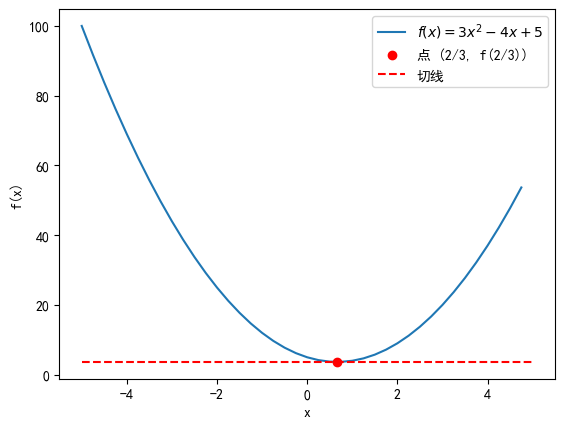

In [11]:
xs = np.arange(-5, 5, 0.25)
ys = func(xs)
# 绘制函数曲线
plt.plot(xs, ys, label="$f(x)=3x^2 - 4x + 5$")

# 在 x = 2/3 处计算函数值和导数（切线斜率）
x0 = 2 / 3
y0 = func(x0)
slope = analytic_derivative(func, x0)

# 标记点 (2/3, f(2/3))
plt.plot(x0, y0, 'ro', label="点 (2/3, f(2/3))")

# 构造切线: y = slope*(x - x0) + y0
tangent_x = np.linspace(-5, 5, 200)
tangent_y = slope * (tangent_x - x0) + y0
plt.plot(tangent_x, tangent_y, 'r--', label="切线")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

In [17]:
a = 2.0
b = -3.0
c = 10.0
d0 = a * b + c
print(f"d0: {d0}")

h = 1e-4
c += h
d1 = a * b + c
print(f"d1: {d1}")

slop = (d1 - d0) / h
print(f"rate of change: {slop}")

d0: 4.0
d1: 4.0001
rate of change: 0.9999999999976694


Value(data=4.0)


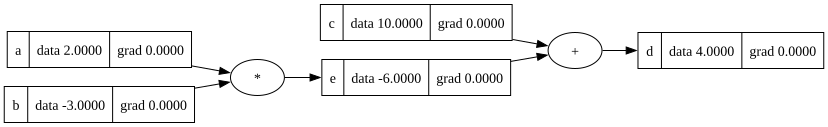

In [42]:
from graphviz import Digraph


def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label=f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}", shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot


class Value:
    def __init__(self, data, _children={}, _operation="", label=""):
        self.data = data
        self._prev = set(_children)
        self._op = _operation
        self.label = label
        self.grad = 0.0

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other: "Value"):
        data_ = self.data + other.data
        children_ = (self, other)
        operation_ = "+"
        def _backward():
            self.grad += other.grad
        return Value(data_, children_, operation_)

    def __mul__(self, other: "Value"):
        data_ = self.data * other.data
        children_ = (self, other)
        operation_ = "*"
        return Value(data_, children_, operation_)


a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a * b
e.label = "e"
d = e + c
d.label = "d"
print(d)
d._prev
d._op
draw_dot(d)

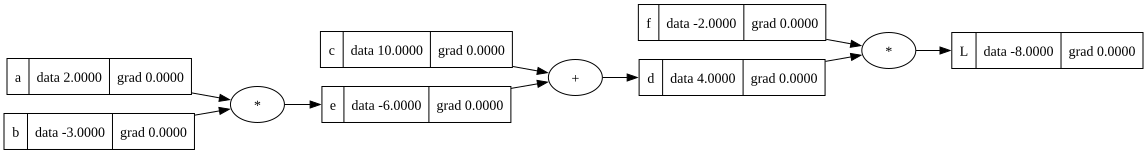

In [43]:
f = Value(-2.0, label="f")
L = d * f;
L.label = "L"
draw_dot(L)